# Sentiment Analysis - Statefull LangGraph Workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

from typing import TypedDict, Literal
import dotenv
import os

import pydantic

In [2]:
dotenv.load_dotenv(override=True)

True

## Overview

In [3]:

class SentimentSchema(pydantic.BaseModel):
    """
    BaseModel (blueprint)
        Ensures any data coming through matches this exact structure
    Literal (strict constraint)
        It tells the AI: "You are only allowed to pick one of these words."
        It prevents the AI from saying any other word.
    Field Description:
        This is a hint for the LLM.
        A post-it note telling the AI exactly what it should be looking for in the text.
    """
    sentiment: Literal['Positive', 'Negetive'] = pydantic.Field(description="Sentiment Analysis of the Customer review")


class DiagnosisSchema(pydantic.BaseModel):
    issue_type: Literal["UX/UI", "Performace", "Bug", "Support", "Other"] = pydantic.Field(description= "The category of issue mentioned in the review")
    tone: Literal["Angry", "Frustated", "Disappointed", "Calm"] = pydantic.Field(description= "The emotional tone expressed by the user in review")
    urgency: Literal["Low", "Medium", "High"] = pydantic.Field(description= "How urgent the issue appears to be")

In [4]:
def get_grok_llm():
    return ChatOpenAI(
    model="openai/gpt-oss-120b",
    stream_usage=True,
    temperature=0.5,
    max_tokens=1000,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url=os.getenv("GROQ_BASE_URL"),
)
llm = get_grok_llm()

In [5]:
structured_model_1 = llm.with_structured_output(SentimentSchema)
structured_model_2 = llm.with_structured_output(DiagnosisSchema)

# Without any prompt
# llm.invoke(f'Answer the following question {question}').content
review= "It was really a bad product"
structured_model_1.invoke(review).sentiment

'Negetive'

In [6]:
structured_model_2.invoke(review)

DiagnosisSchema(issue_type='Other', tone='Disappointed', urgency='Low')

## Goal
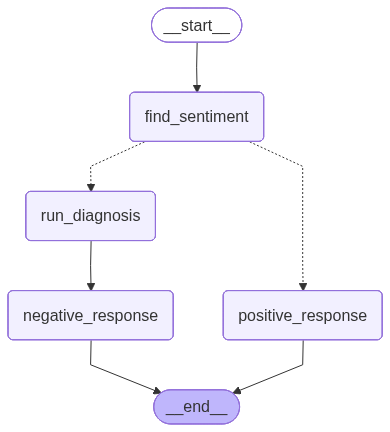

## State (Shared Memory)

In [7]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['Positive', 'Negetive']
    diagnosis: dict
    response: str

## Nodes (Worker)

In [8]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review comment, find the sentiment: {state["review"]}'
    sentiment = structured_model_1.invoke(prompt).sentiment
    return {'sentiment': sentiment}

In [9]:
def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [10]:
def positive_response(state: ReviewState):
    prompt = f'Write a warm thank you in your response based on the review of the customer {state["review"]}'
    response = llm.invoke(prompt).content
    return {'response': response}

In [11]:
def run_diagnosis(state: ReviewState):
    prompt = f"Run diagnosis for the customer review: \n{state['review']}"
    raw_response = structured_model_2.invoke(prompt)
    return {'diagnosis': raw_response.model_dump()}

In [12]:
def negative_response(state: ReviewState):
    prompt = f"""You are a support assistant. \n
        The user had a {state['diagnosis']}, sounded {state['diagnosis']['tone']} and
        marked urgency as {state['diagnosis']['urgency']}. \n
        Write an empathetic, helpful response message.
        """
    response = llm.invoke(prompt).content
    return {'response': response}

## Graph Construction

In [13]:
# 1. Graph Initialize with the state schema
graph = StateGraph(ReviewState)

# 2. Add the worker to the graph
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)

# 3. Add edges
graph.add_edge(START, 'find_sentiment')

# Instead of hardcoding the next step, you pass it a function (check_sentiment).
# The graph runs this function, looks at the output, and decides where to go next dynamically.
graph.add_conditional_edges(
    'find_sentiment',
    check_sentiment,
    {
        "positive_response": "positive_response", # Label "positive_response" points to the positive node
        "run_diagnosis": "run_diagnosis"          # Label "run_diagnosis" points to the diagnosis node
    }
)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

## Machine

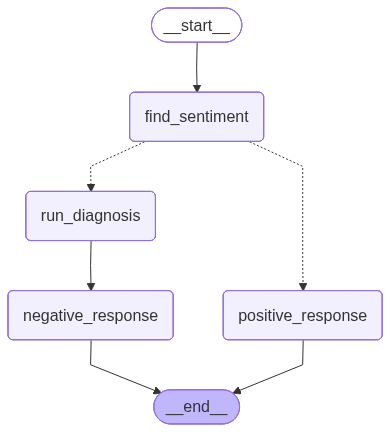

In [14]:
workflow = graph.compile()
workflow

## Call to LLM

### Frustrating customer

In [15]:
intial_state= {
    'review': "I have been trying to log in for over an hour now, & app is keep stucking, really frustrating."
}
workflow.invoke(intial_state)

{'review': 'I have been trying to log in for over an hour now, & app is keep stucking, really frustrating.',
 'sentiment': 'Negetive',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'Frustated', 'urgency': 'High'},
 'response': 'Hi there,\n\nI’m really sorry you’re running into this issue—it’s completely understandable how frustrating that can be, especially when you need things to work right away. Let’s get this sorted out as quickly as possible.\n\n**Here’s what we can do next:**\n\n1. **Gather a few details**  \n   - The exact steps you took before the bug appeared.  \n   - Any error messages or screenshots you can share.  \n   - The device, operating system, and app version you’re using.\n\n2. **Try a quick reset** (if you haven’t already)  \n   - Close the app/computer completely, then reopen it.  \n   - Clear the app’s cache (Settings\u202f→\u202fStorage\u202f→\u202fClear Cache) or restart your device.  \n\n3. **Check for updates**  \n   - Make sure you’re on the latest version of t

### Angry Customer (Streaming)

In [16]:
intial_state = {
    'review': "Your latest update wiped all my saved data! I am furious, fix this now!"
}
loop = 0

# Streaming shows the output of each node as it finishes
for event in workflow.stream(intial_state):
    for node_name, node_state in event.items():
        loop += 1
        print(f"{loop} Node Executed: {node_name} and {node_state} ---")
        # Print specific updates
        if 'diagnosis' in node_state:
            print(f"{loop} Tone detected: {node_state['diagnosis']['tone']}")

1 Node Executed: find_sentiment and {'sentiment': 'Negetive'} ---
2 Node Executed: run_diagnosis and {'diagnosis': {'issue_type': 'Bug', 'tone': 'Angry', 'urgency': 'High'}} ---
2 Tone detected: Angry
3 Node Executed: negative_response and {'response': 'Hi there,\n\nI’m really sorry you’re experiencing this problem—it’s completely understandable how frustrating that can be, especially when you need things to work right away. Let’s get this sorted out as quickly as possible.\n\n**What we can do right now**\n\n1. **Quick check** – Could you let me know the exact steps you took before the issue appeared, and any error messages you’re seeing? A screenshot (if possible) would be incredibly helpful.\n2. **Immediate work‑around** – If you haven’t already, try clearing your browser cache or restarting the app. Often this resolves temporary glitches.\n3. **Priority escalation** – I’ve flagged this as a high‑urgency bug and will route it straight to our engineering team. As soon as we have an up

### Happy Customer (Direct Invocation)

In [17]:
intial_state = {
    'review': "Just wanted to say I love the new dark mode feature. Great job team!"
}

final_state = workflow.invoke(intial_state)
print("Sentiment:", final_state['sentiment'])
print("AI Response:", final_state['response'])
# Notice that final_state['diagnosis'] will not exist here because that node was bypassed!

Sentiment: Positive
AI Response: Hi there,

Thank you for reaching out. I understand you’re experiencing some UX/UI concerns, and I’m happy to help you sort them out.

Could you let me know a bit more about what you’re seeing? For example:

* Which page or screen is giving you trouble?
* Are there specific elements (buttons, menus, forms, etc.) that don’t look or behave as expected?
* Are you using a particular device or browser when this occurs?
* If you’ve noticed any error messages or visual glitches, a screenshot would be really helpful.

With a few more details I’ll be able to pinpoint the issue and suggest the best steps to improve the experience. In the meantime, you might try clearing your browser cache or refreshing the page—sometimes that resolves minor UI glitches.

Looking forward to your reply so we can get this sorted for you!


# Self-Correcting  BlogWriter
An AI **writes a blog** post, a **Critique AI** reviews it.<br>
If it's not good enough, it **routes back to the writer** to try again.

The Reducer `operator.add`:
- In your first code, `state['review']` was overwritten if changed.
- Here, `revision_count` uses a reducer `operator.add`. This tells LangGraph: 
    - **When a node returns `{"revision_count": 1}`, don't set the count to 1**.
    - Add 1 to whatever the current count is. 

The Failsafe: We include `state["revision_count"] >= 3` in the conditional edge. What not to do
- Never create a cyclic graph without a hard limit.
- LLMs can be stubborn, and if the critique node never says "Looks good!", the graph will loop forever, burning through your API tokens.

In [18]:
from typing import Annotated
import operator

# 1. State with a Reducer (Annotated)
class WriterState(TypedDict):
    topic: str
    draft: str
    feedback: str
    # operator.add ensures we add to the count, not overwrite it
    revision_count: Annotated[int, operator.add]

# 2. Nodes
def draft_content(state: WriterState):
    print(f"Writing draft (Attempt {state.get('revision_count', 0) + 1})...")
    # Mock LLM call
    draft = f"Here is a blog post about {state['topic']} based on the feedback: {state.get('feedback', 'None')}."
    return {"draft": draft, "revision_count": 1} # Adds 1 to the count

def critique_content(state: WriterState):
    print("Critiquing draft...")
    # Mock LLM determining if it's good enough
    if state['revision_count'] >= 3:
         feedback = "Looks good!"
    else:
         feedback = "Needs more detail."
    return {"feedback": feedback}

# 3. Conditional Logic
def route_critique(state: WriterState) -> Literal["draft_content", "__end__"]:
    # If the critique says it's good, or we've looped 3 times (to prevent infinite loops)
    if state["feedback"] == "Looks good!" or state["revision_count"] >= 3:
        return "__end__"
    # Otherwise, loop back to the writer
    return "draft_content"

# 4. Graph Construction
writer_graph = StateGraph(WriterState)

writer_graph.add_node("draft_content", draft_content)
writer_graph.add_node("critique_content", critique_content)

writer_graph.add_edge(START, "draft_content")
writer_graph.add_edge("draft_content", "critique_content")

# This creates a CYCLE. It loops back to the draft node.
writer_graph.add_conditional_edges(
    "critique_content",
    route_critique,
    {"draft_content": "draft_content", "__end__": END}
)

app = writer_graph.compile()

# 5. Invocation
app.invoke({"topic": "AI in Healthcare", "revision_count": 0})

Writing draft (Attempt 1)...
Critiquing draft...
Writing draft (Attempt 2)...
Critiquing draft...
Writing draft (Attempt 3)...
Critiquing draft...


{'topic': 'AI in Healthcare',
 'draft': 'Here is a blog post about AI in Healthcare based on the feedback: Needs more detail..',
 'feedback': 'Looks good!',
 'revision_count': 3}

# Autonomous Newsroom Code
**Reducer**
Without this reducer, if Node A returns a piece of feedback and then Node B returns a new piece of feedback, LangGraph would default to completely overwriting the existing key. Your agent would suffer from "amnesia," only remembering the absolute last update it received.

To validate and test **The Autonomous Newsroom** architecture,<br>
- Prompt the graph by passing an initial state and managing the thread configuration

- Because this specific graph uses **Checkpoints (Memory)** and **Interrupts (Human-in-the-Loop)**, you cannot just use a simple `.invoke()`.

- You must pass a **thread_id** so LangGraph knows which conversation it is pausing and resuming.

In [1]:
from typing import Annotated, TypedDict, List, Literal
import operator
import os
import pydantic
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import dotenv

dotenv.load_dotenv(override=True)

# --- 1. LLM Setup ---
def get_grok_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-120b",
        stream_usage=True,
        temperature=0.5, # Slightly creative for writing
        max_tokens=1000,
        api_key=os.getenv("GROQ_API_KEY"),
        base_url=os.getenv("GROQ_BASE_URL"),
    )

llm = get_grok_llm()

# Create a strict fact-checking version of your LLM
class FactCheckSchema(pydantic.BaseModel):
    fact_score: int = pydantic.Field(description="Score from 1 to 10 evaluating factual accuracy.")
    feedback: str = pydantic.Field(description="Specific feedback on what is missing or incorrect.")

strict_fact_checker_llm = llm.with_structured_output(FactCheckSchema)

# --- 2. State Definition ---
class NewsState(TypedDict):
    topic: str
    draft: str
    feedback_history: Annotated[List[str], operator.add]
    revision_count: Annotated[int, operator.add]
    fact_score: int
    editor_approved: bool

# --- 3. The LLM Nodes ---
def writer_agent(state: NewsState):
    print(f"--> [Writer] Drafting article on: {state['topic']} (Attempt {state.get('revision_count', 0) + 1})")

    # Construct the prompt using the state memory
    system_prompt = "You are an expert news journalist. Write a concise, 2-paragraph article on the provided topic."
    human_prompt = f"Topic: {state['topic']}\n"

    if state.get("feedback_history"):
        human_prompt += f"\nCritique to address: {state['feedback_history'][-1]}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=human_prompt)
    ]

    # Actual LLM Call
    response = llm.invoke(messages)
    return {"draft": response.content, "revision_count": 1}

def fact_checker_agent(state: NewsState):
    print("--> [Fact Checker] Verifying claims via LLM...")

    system_prompt = "You are a strict, Pulitzer-winning fact-checker. Evaluate the following draft."
    human_prompt = f"Topic: {state['topic']}\n\nDraft: {state['draft']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=human_prompt)
    ]

    # Actual Structured LLM Call
    structured_response = strict_fact_checker_llm.invoke(messages)

    print(f"    *LLM Fact Score: {structured_response.fact_score}*")
    print(f"    *LLM Feedback: {structured_response.feedback}*")

    return {
        "fact_score": structured_response.fact_score,
        "feedback_history": [structured_response.feedback]
    }

def human_editor_node(state: NewsState):
    print("--> [Human Editor] Graph paused. Waiting for human approval...")
    return {}

def publisher_agent(state: NewsState):
    print("--> [Publisher] Formatting final output...")
    # A simple LLM call to format the final text
    prompt = f"Format this text for a website publication with a catchy headline:\n\n{state['draft']}"
    response = llm.invoke(prompt)
    return {"draft": response.content}

# --- 4. Routing Logic - Bug---
# def route_after_fact_check(state: NewsState) -> Literal["writer_agent", "human_editor_node"]:
#     if state["fact_score"] < 8:
#         print("    *Score too low. Routing back to Writer.*")
#         return "writer_agent"
#
#     if state["revision_count"] >= 3:
#         print("    *Max revisions reached. Pushing to editor anyway.*")
#
#     return "human_editor_node"

# --- 4. Routing Logic - Fixed ---
def route_after_fact_check(state: NewsState) -> Literal["writer_agent", "human_editor_node"]:
    if state["revision_count"] >= 3:
        print("    *Max revisions reached. Pushing to editor anyway.*")
        return "human_editor_node"

    if state["fact_score"] < 8:
        print("    *Score too low. Routing back to Writer.*")
        return "writer_agent"

    print("    *Factual score passed. Routing to Human Editor.*")
    return "human_editor_node"

def route_after_editor(state: NewsState) -> Literal["writer_agent", "publisher_agent"]:
    if not state.get("editor_approved", False):
         print("    *Human rejected. Routing back to Writer.*")
         return "writer_agent"
    return "publisher_agent"

# --- 5. Graph Compilation ---
workflow = StateGraph(NewsState)

workflow.add_node("writer_agent", writer_agent)
workflow.add_node("fact_checker_agent", fact_checker_agent)
workflow.add_node("human_editor_node", human_editor_node)
workflow.add_node("publisher_agent", publisher_agent)

workflow.add_edge(START, "writer_agent")
workflow.add_edge("writer_agent", "fact_checker_agent")

workflow.add_conditional_edges(
    "fact_checker_agent",
    route_after_fact_check,
    {"writer_agent": "writer_agent", "human_editor_node": "human_editor_node"}
)

workflow.add_conditional_edges(
    "human_editor_node",
    route_after_editor,
    {"writer_agent": "writer_agent", "publisher_agent": "publisher_agent"}
)

workflow.add_edge("publisher_agent", END)

memory = MemorySaver()
app = workflow.compile(
    checkpointer=memory,
    interrupt_before=["human_editor_node"]
)

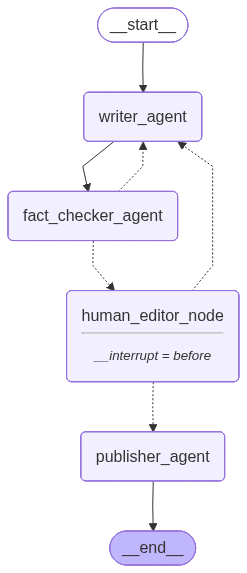

In [25]:
app

### Scenario 1: Initiating the Workflow & Hitting the Interrupt
This scenario proves that your graph can **start**, **process data**, and **correctly pause** when it reaches a **protected action**.

`config_main = {"configurable": {"thread_id": "news_story_001"}}`<br>
This is the secret to LangGraph's memory. When you use `MemorySaver()`, you must provide a `thread_id`. All history for this specific article is saved in `thread_id` (news_story_001.)

`initial_state = {...}`<br>
We are manually defining the starting conditions: the topic, zero revisions, and an empty feedback list.

`app.stream(initial_state, config_main)`<br>
Stream runs the graph step-by-step. The graph processes the writer and fact-checker. If the fact-checker gives a high score, the routing logic says "go to the human editor." However, because we set interrupt_before=["human_editor_node"] during compilation, the graph freezes execution right before that node and saves its state into the news_story_001 thread.

In [20]:
# A thread configuration is REQUIRED when using memory (MemorySaver)
config_main = {"configurable": {"thread_id": "news_story_001"}}

# The initial State
initial_state = {
    "topic": "The impact of quantum computing on cryptography",
    "revision_count": 0,
    "feedback_history": []
}

print("--- SCENARIO 1: Starting Workflow ---")
# Using stream to watch it step-by-step
for event in app.stream(initial_state, config_main):
    for node_name, state_update in event.items():
        print(f"Finished step: {node_name}")

print("-> Graph is now paused at the human_editor_node interrupt.\n")

--- SCENARIO 1: Starting Workflow ---
--> [Writer] Drafting article on: The impact of quantum computing on cryptography (Attempt 1)
Finished step: writer_agent
--> [Fact Checker] Verifying claims via LLM...
    *LLM Fact Score: 7*
    *LLM Feedback: The draft correctly describes Shor's algorithm, the current size of quantum prototypes, Google’s 2023 logical‑qubit demonstration, and IBM’s 1,000‑qubit roadmap, and it accurately notes that governments view quantum‑risk as strategic. However, it misstates the NIST process: as of July 2024 NIST has not completed a "fourth round" of PQC selection; the final round (Round 3) was announced in 2022, and standardization is expected around 2024‑2025, not a 2026 deadline. The claim that major firms have already integrated the yet‑unstandardized candidates into production TLS libraries is overstated – only experimental or pilot integrations exist. Correct these points (NIST timeline, status of industry adoption) to improve factual accuracy.*
    *Sc

### Scenario 2: Human Editor Rejects the Draft

This scenario proves that you can wake up a sleeping graph, inject a human decision, and successfully trigger a loop backward.

app.update_state(config_main, {"editor_approved": False, "feedback_history": ["..."]})

The "Why": The graph is paused. This line acts as the human intervention. We target the specific news_story_001 thread and update its memory. We set approval to False and add a new critique. Because feedback_history uses an operator.add reducer, this new critique is appended to the list of previous feedback, not replacing it.

app.stream(None, config_main)

The "Why": Passing None as the input state is the magic command for "resume." It tells LangGraph: "Do not start over. Wake up the thread news_story_001 and continue from exactly where you paused." The graph wakes up, triggers the route_after_editor logic, sees editor_approved is False, and loops back to the writer node.

In [21]:
print("--- SCENARIO 2: Human Editor Rejects ---")
# 1. Update the state with a rejection and new feedback
app.update_state(
    config_main,
    {
        "editor_approved": False,
        "feedback_history": ["Human Editor: The tone is too casual. Please rewrite."]
    }
)

# 2. Resume the graph by passing None
for event in app.stream(None, config_main):
    for node_name, state_update in event.items():
        print(f"Finished step: {node_name}")

print("-> Graph looped back and is now paused again at the human_editor_node interrupt.\n")

--- SCENARIO 2: Human Editor Rejects ---
    *Max revisions reached. Pushing to editor anyway.*
--> [Human Editor] Graph paused. Waiting for human approval...
    *Human rejected. Routing back to Writer.*
Finished step: human_editor_node
--> [Writer] Drafting article on: The impact of quantum computing on cryptography (Attempt 4)
Finished step: writer_agent
--> [Fact Checker] Verifying claims via LLM...
    *LLM Fact Score: 9*
    *LLM Feedback: The draft is largely accurate: quantum computers threaten RSA, DSA, ECC via Shor's algorithm, and NIST’s post‑quantum standardisation effort is indeed underway. Minor issues: as of 2026 NIST has already published its final PQC selections, so “nearing finalisation” is outdated. The timeline for practical, fault‑tolerant quantum computers remains speculative and should be qualified further. Adding brief mention of leading PQC families (e.g., lattice‑based, code‑based) would strengthen completeness.*
    *Max revisions reached. Pushing to editor a

### Scenario 3: Human Editor Approves the Draft

Assuming the graph is paused again after the rewrite in Scenario 2, we will now simulate the human approving the draft, allowing it to proceed to the Publisher.

In [22]:
print("--- SCENARIO 3: Human Editor Approves ---")
# 1. Update the state with an approval
app.update_state(
    config_main,
    {"editor_approved": True}
)

# 2. Resume the graph (using invoke to just get the final output)
final_output = app.invoke(None, config_main)

print("Finished step: publisher_agent")
print("\n=== FINAL PUBLISHED ARTICLE ===")
print(final_output["draft"])
print("===============================\n")

--- SCENARIO 3: Human Editor Approves ---
    *Max revisions reached. Pushing to editor anyway.*
--> [Human Editor] Graph paused. Waiting for human approval...
--> [Publisher] Formatting final output...
Finished step: publisher_agent

=== FINAL PUBLISHED ARTICLE ===
**HTML + Markdown‑ready layout**

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Quantum Computing vs. Cryptography: Why the Race to Post‑Quantum Security Has Already Begun</title>
    <meta name="description"
          content="Quantum computers threaten RSA, ECC and other public‑key schemes. Learn how post‑quantum cryptography (PQC) is being standardized and why organisations must start migrating today.">
    <link rel="stylesheet" href="styles.css"><!-- optional -->
</head>
<body class="article">

<header class="hero">
    <h1 class="hero__title">
        Quantum Computing vs. Cryptography: Why the Race to Post‑Quantum Security Has Already Begun
    </h1>
    <p class="hero__subtitl

### Scenario 4: Testing the Max Revisions Failsafe (Bug)
To test the token protection failsafe, we use a new thread ID and inject a state that has already hit the maximum allowed revisions, even with a failing fact score.

In [ ]:
print("--- SCENARIO 4: Testing the Token Failsafe - Bug ---")
# Use a new thread ID so it doesn't conflict with our previous test
config_failsafe = {"configurable": {"thread_id": "news_story_failsafe_test"}}

failsafe_state = {
    "topic": "Market Trends 2026",
    "revision_count": 3, # Simulating that it has already looped 3 times
    "fact_score": 2,     # A terrible score that would normally trigger a loop
    "feedback_history": []
}

# Run the graph
for event in app.stream(failsafe_state, config_failsafe):
    for node_name, state_update in event.items():
        print(f"Finished step: {node_name}")

print("-> Notice how the routing logic skipped the loop and pushed it to the human_editor_node anyway to save tokens.")

--- SCENARIO 4: Testing the Token Failsafe ---
--> [Writer] Drafting article on: Market Trends 2026 (Attempt 4)
Finished step: writer_agent
--> [Fact Checker] Verifying claims via LLM...
    *LLM Fact Score: 3*
    *LLM Feedback: The draft makes several specific quantitative claims (e.g., AI platforms >40% of enterprise spend, 28% YoY rise in green‑bond issuance, $115 bn VC to green‑tech in H1 2026, mobile commerce 62% of global retail sales, Southeast Asia $3.2 trn market by 2027) without citing any sources. Many of these figures are inconsistent with publicly available data (e.g., global e‑commerce accounts for ~20‑25% of total retail sales, not 62%; AI spend share is lower than 40%). The lack of verifiable references and apparent exaggeration reduce factual reliability, resulting in a low accuracy score. Provide sourced statistics or adjust figures to align with established reports to improve credibility.*
    *Score too low. Routing back to Writer.*
Finished step: fact_checker_agen

In [2]:
print("--- SCENARIO 5: Testing the Token Failsafe - Fixed ---")
# Use a new thread ID so it doesn't conflict with our previous test
config_failsafe = {"configurable": {"thread_id": "news_story_failsafe_test"}}

failsafe_state = {
    "topic": "Market Trends 2026",
    "revision_count": 3, # Simulating that it has already looped 3 times
    "fact_score": 2,     # A terrible score that would normally trigger a loop
    "feedback_history": []
}

# Run the graph
for event in app.stream(failsafe_state, config_failsafe):
    for node_name, state_update in event.items():
        print(f"Finished step: {node_name}")

print("-> Notice how the routing logic skipped the loop and pushed it to the human_editor_node anyway to save tokens.")

--- SCENARIO 4: Testing the Token Failsafe ---
--> [Writer] Drafting article on: Market Trends 2026 (Attempt 4)
Finished step: writer_agent
--> [Fact Checker] Verifying claims via LLM...
    *LLM Fact Score: 3*
    *LLM Feedback: The draft makes several specific quantitative claims (e.g., AI‑driven automation powering >70% of supply‑chain decisions in the US/EU, $1.3 trillion in sustainable‑bond issuances in 2026, $250 billion in mobile‑first commerce sales in India and Sub‑Saharan Africa, and wages outpacing the global average by 3.5 percentage points) without citing any sources. These figures are not corroborated by publicly available data and appear to be speculative or exaggerated. To improve factual accuracy, provide verifiable references for each statistic, temper projections that are not yet supported by empirical evidence, and avoid presenting unverified numbers as established facts.*
    *Max revisions reached. Pushing to editor anyway.*
Finished step: fact_checker_agent
Finis